In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from matplotlib.ticker import ScalarFormatter

In [2]:
import sys, types
import numpy.core.numeric as _nc
_np_core = types.ModuleType("numpy._core")
_np_core.numeric = types.ModuleType("numpy._core.numeric")
_np_core.numeric.__dict__.update(_nc.__dict__)
sys.modules["numpy._core"] = _np_core
sys.modules["numpy._core.numeric"] = _np_core.numeric

# SCP Method

In [22]:
base_path   = r"C:\Users\MGA5500\Desktop\PROJECT\WW\Data"
calib_seeds = list(range(60, 69))
test_seed   = 69
timesteps   = [25, 160]
nx          = 250
alpha       = 0.10
slices      = {'u': slice(0, nx), 'h': slice(nx, 2*nx), 'r': slice(2*nx, 3*nx)}

t=25  thresholds: {'u': 0.0015948158923944078, 'h': 0.014618767467439397, 'r': 0.0018740563265190167}


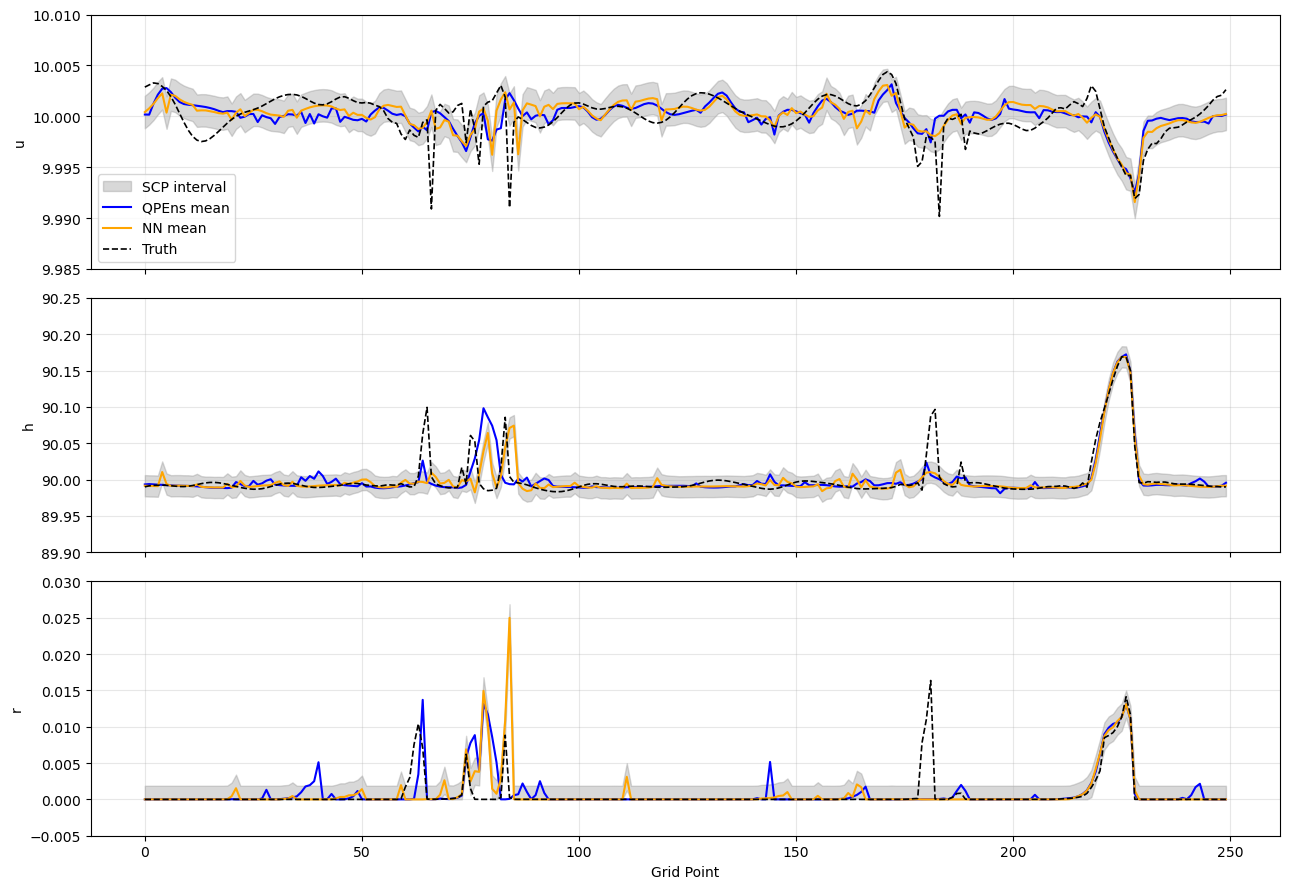

t=160  thresholds: {'u': 0.0013682886523138649, 'h': 0.01349146549110003, 'r': 0.0019431310085878048}


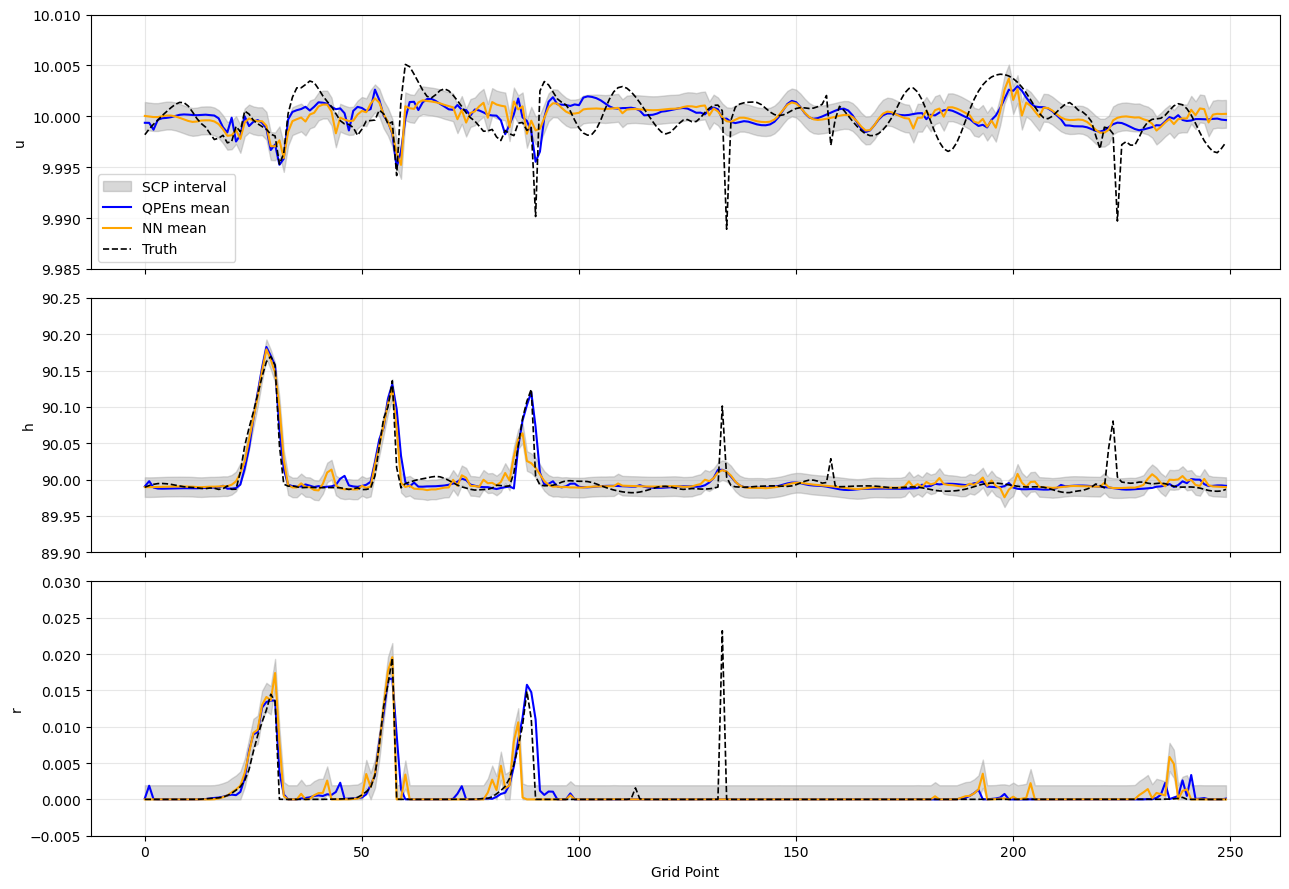

In [23]:
def load_means_and_truth(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    with open(os.path.join(path, 'truth_data.pkl'), 'rb') as f:
        truth = pickle.load(f)
    nn_arr    = np.asarray(nn['analysis'][t])
    qpens_arr = np.asarray(qpens['analysis'][t])
    truth_arr = np.asarray(truth[t])
    nn_mean    = {v: nn_arr   [sl, :].mean(axis=1) for v, sl in slices.items()}  
    qpens_mean = {v: qpens_arr[sl, :].mean(axis=1) for v, sl in slices.items()}  
    truth_d    = {v: truth_arr[sl]                 for v, sl in slices.items()}
    return nn_mean, qpens_mean, truth_d


def compute_scp_threshold(t):
    nn_cal, qp_cal = {v: [] for v in slices}, {v: [] for v in slices}
    for seed in calib_seeds:
        try:
            nn_mean, qpens_mean, _ = load_means_and_truth(seed, t)  
            for v in slices:
                nn_cal[v].append(nn_mean   [v])   
                qp_cal[v].append(qpens_mean[v])   
        except Exception as e:
            print(f"seed={seed}, t={t}: {e}")

    thresholds = {}
    for v in slices:
        if not nn_cal[v]:
            thresholds[v] = np.nan
            continue
        nn_stack    = np.stack(nn_cal[v], axis=0)    
        qpens_stack = np.stack(qp_cal[v], axis=0)    
        scores = np.abs(qpens_stack - nn_stack).ravel()
        N      = scores.size
        qprob  = float(np.ceil((N + 1) * (1 - alpha)) / N)
        thresholds[v] = float(np.quantile(scores, qprob, method="inverted_cdf"))
    return thresholds


YLIMS = {'u': (9.985, 10.010), 'h': (89.90, 90.25), 'r': (-0.005, 0.030)}
YSTEP = {'u': 0.005, 'h': 0.05, 'r': 0.005}

def plot_scp_snapshot(t, thresholds, seed):
    nn_mean, qpens_mean, truth_d = load_means_and_truth(seed, t) 
    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    for ax, v in zip(axes, slices):
        nn_line    = np.asarray(nn_mean   [v])
        qpens_line = np.asarray(qpens_mean[v])
        truth_line = np.asarray(truth_d   [v])
        x = np.arange(nn_line.size)
        qv = thresholds.get(v, np.nan)
        if np.isfinite(qv):
            lower = nn_line - qv
            upper = nn_line + qv
            if v == 'r':
                lower = np.maximum(lower, 0)
                upper = np.maximum(upper, 0)

            ax.fill_between(x, lower, upper, alpha=0.3, color='gray', label='SCP interval')
        ax.plot(x, qpens_line, color='blue',   linewidth=1.5, label='QPEns mean')
        ax.plot(x, nn_line,    color='orange',  linewidth=1.5, label='NN mean')
        ax.plot(x, truth_line, color='black', linestyle='--', linewidth=1.2, label='Truth')
        ax.set_ylabel(v)
        ax.grid(True, alpha=0.3)
        if v in YLIMS:
            ax.set_ylim(YLIMS[v])
            ax.set_yticks(np.arange(YLIMS[v][0], YLIMS[v][1] + YSTEP[v]*0.5, YSTEP[v]))
        if v == 'u':
            ax.legend(loc='lower left', frameon=True)
    axes[-1].set_xlabel("Grid Point")
    fig.tight_layout()
    plt.show()


for t in timesteps:
    thresh = compute_scp_threshold(t)
    print(f"t={t}  thresholds: {thresh}")
    plot_scp_snapshot(t, thresh, test_seed)

# NCP Method

In [25]:
base_path      = r"C:\Users\MGA5500\Desktop\PROJECT\WW\Data"
calib_seeds    = list(range(60, 69))
test_seed      = 69
timesteps      = [25, 160]
nx             = 250
alpha          = 0.10
slices = {'u': slice(0, nx), 'h': slice(nx, 2*nx), 'r': slice(2*nx, 3*nx)}

t=25  thresholds: {'u': 1.270301663949362, 'h': 2.201928775469986, 'r': 0.0018740563265190167}


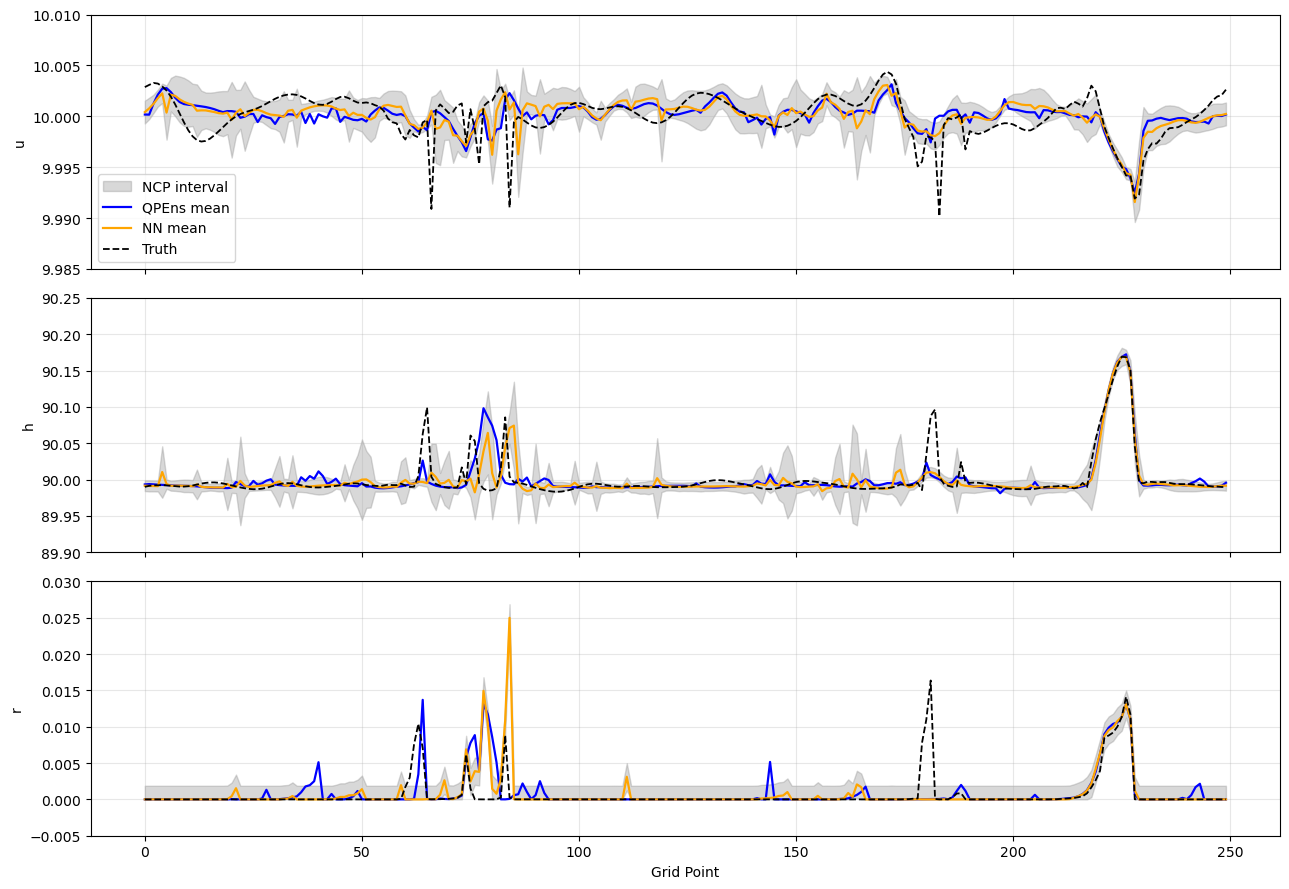

t=160  thresholds: {'u': 1.140960029390045, 'h': 2.013571744186535, 'r': 0.0019431310085878048}


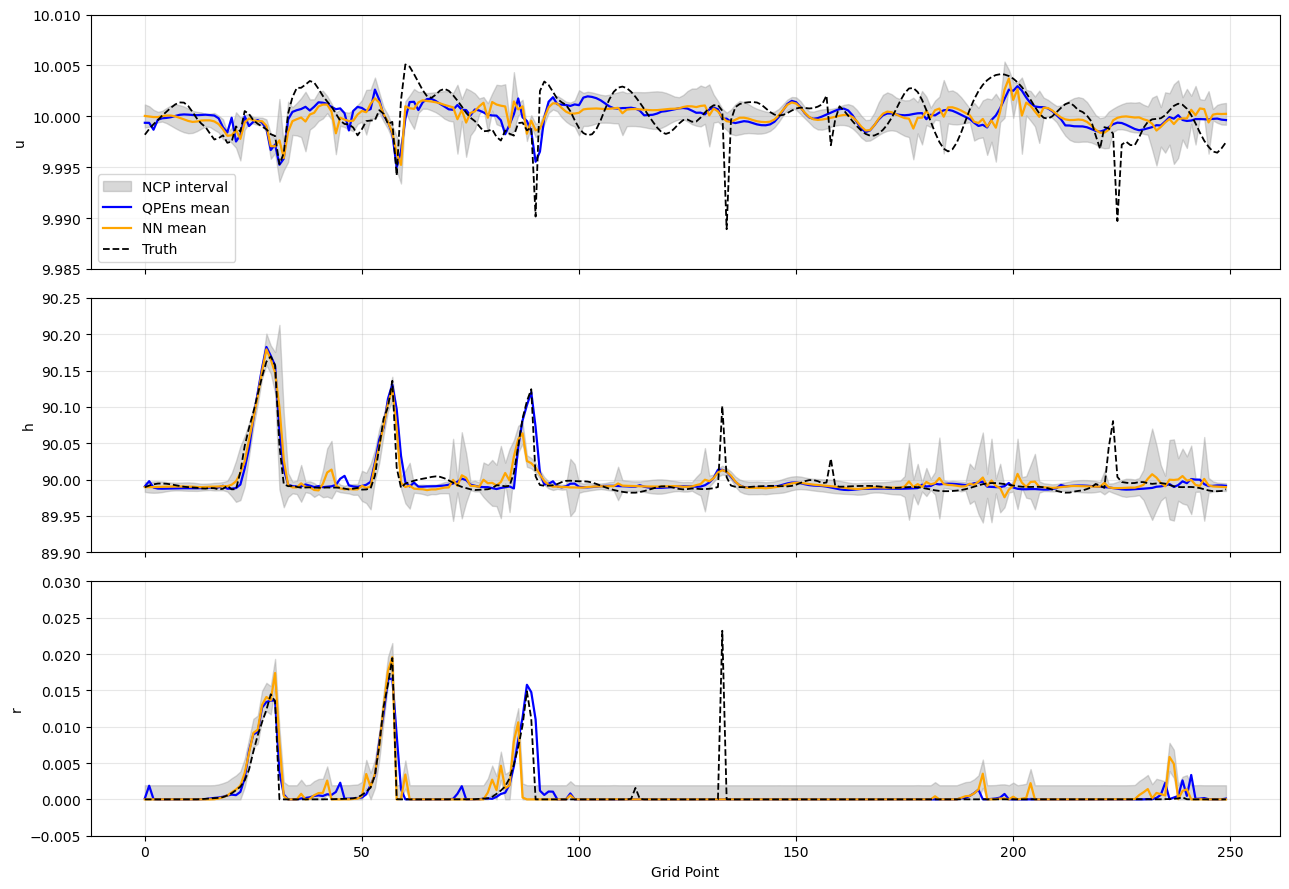

In [26]:
def load_means_std_and_truth(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    with open(os.path.join(path, 'truth_data.pkl'), 'rb') as f:
        truth = pickle.load(f)

    arr_nn    = np.asarray(nn['analysis'][t])      
    arr_qpens = np.asarray(qpens['analysis'][t])    
    truth_arr = np.asarray(truth[t])

    nn_mean    = {v: arr_nn   [sl, :].mean(axis=1) for v, sl in slices.items()}  
    nn_std     = {v: arr_nn   [sl, :].std(axis=1)  for v, sl in slices.items()}  
    qpens_mean = {v: arr_qpens[sl, :].mean(axis=1) for v, sl in slices.items()}  
    truth_d    = {v: truth_arr[sl]                 for v, sl in slices.items()}

    return nn_mean, nn_std, qpens_mean, truth_d


def compute_ncp_threshold(t):
    nn_cal     = {v: [] for v in slices}
    qp_cal     = {v: [] for v in slices}
    nn_std_cal = {v: [] for v in slices}

    for seed in calib_seeds:
        try:
            nn_mean, nn_std, q_mean, _ = load_means_std_and_truth(seed, t)
            for v in slices:
                nn_cal    [v].append(nn_mean[v])   
                qp_cal    [v].append(q_mean [v])  
                nn_std_cal[v].append(nn_std [v])   
        except Exception as e:
            print(f"seed={seed}, t={t}: {e}")

    thresholds = {}
    for v in slices:
        if not nn_cal[v]:
            thresholds[v] = np.nan
            continue

        nn_stack  = np.stack(nn_cal    [v], axis=0)   
        qp_stack  = np.stack(qp_cal    [v], axis=0)   
        std_stack = np.stack(nn_std_cal[v], axis=0)   
        res_cal   = np.abs(qp_stack - nn_stack)       

        if v in ('u', 'h'):
            std_stack = np.maximum(std_stack, 1e-8)   
            scores    = res_cal / std_stack           
        else:
            scores = res_cal                         

        scores = scores[np.isfinite(scores)]
        N      = scores.size
        qprob  = float(np.ceil((N + 1) * (1 - alpha)) / N)
        thresholds[v] = float(np.quantile(scores.ravel(), qprob, method="inverted_cdf"))

    return thresholds

YLIMS_NCP = {'u': (9.985, 10.010), 'h': (89.90, 90.25), 'r': (-0.005, 0.030)}
YSTEP_NCP = {'u': 0.005, 'h': 0.05, 'r': 0.005}

def plot_ncp_snapshot(t, thresholds, seed):
    nn_mean, nn_std, qpens_mean, truth_d = load_means_std_and_truth(seed, t)

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    for ax, v in zip(axes, slices):
        nn_line     = np.asarray(nn_mean   [v])
        nn_std_line = np.asarray(nn_std    [v])
        qpens_line  = np.asarray(qpens_mean[v])
        truth_line  = np.asarray(truth_d   [v])
        x  = np.arange(nn_line.size)
        qv = thresholds.get(v, np.nan)

        if np.isfinite(qv):
            if v in ('u', 'h'):
                nn_std_line = np.maximum(nn_std_line, 1e-8)   
                band = qv * nn_std_line                        
            else:
                band = np.full_like(nn_line, qv)              

            lower = nn_line - band
            upper = nn_line + band
            if v == 'r':
                lower = np.maximum(lower, 0)
                upper = np.maximum(upper, 0)

            ax.fill_between(x, lower, upper, alpha=0.3, color='grey', label='NCP interval')

        ax.plot(x, qpens_line, color='blue',   linewidth=1.6, label='QPEns mean')
        ax.plot(x, nn_line,    color='orange',  linewidth=1.6, label='NN mean')
        ax.plot(x, truth_line, color='black', linestyle='--', linewidth=1.3, label='Truth')
        ax.set_ylabel(v)
        ax.grid(True, alpha=0.3)
        if v in YLIMS_NCP:
            ax.set_ylim(YLIMS_NCP[v])
            ax.set_yticks(np.arange(YLIMS_NCP[v][0], YLIMS_NCP[v][1] + YSTEP_NCP[v]*0.5,
                                    YSTEP_NCP[v]))
        if v == 'u':
            ax.legend(loc='lower left', frameon=True)
            fmt = ScalarFormatter(useOffset=False)
            fmt.set_scientific(False)
            ax.yaxis.set_major_formatter(fmt)

    axes[-1].set_xlabel("Grid Point")
    fig.tight_layout()
    plt.show()

for t in timesteps:
    thresh = compute_ncp_threshold(t)
    print(f"t={t}  thresholds: {thresh}")
    plot_ncp_snapshot(t, thresh, test_seed)

# CQR Method

In [4]:
base_path_cqr = r"C:\Users\MGA5500\Desktop\PROJECT\WW\MSW codes Reimp"
calib_seeds   = list(range(60, 69))
test_seed     = 69
timesteps     = [25, 160]
nx            = 250
alpha         = 0.10
slices = {'u': slice(0, nx), 'h': slice(nx, 2*nx), 'r': slice(2*nx, 3*nx)}
VARS   = ['u', 'h', 'r']

t=25  thresholds: {'u': 0.0008680149099955514, 'h': 0.006810093796744354, 'r': 0.0009501835944299322}


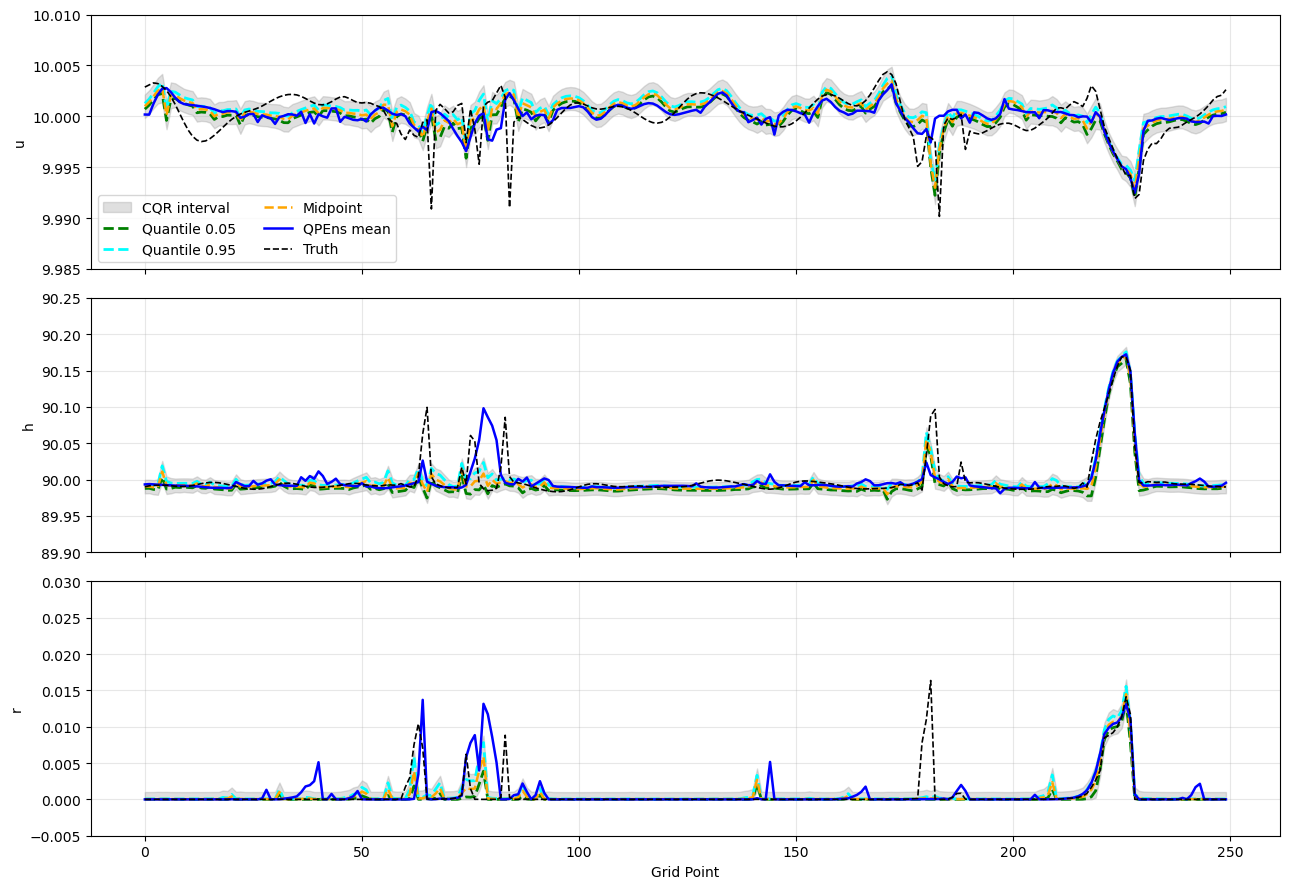

t=160  thresholds: {'u': 0.0008949175223289529, 'h': 0.006485637941494815, 'r': 0.0012449252733768284}


In [ ]:
def load_cqr_data(seed, t):
    path = os.path.join(base_path_cqr, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    with open(os.path.join(path, 'truth_data.pkl'), 'rb') as f:
        truth = pickle.load(f)

    lo_all    = np.asarray(nn['lower'][t])         
    hi_all    = np.asarray(nn['upper'][t])          
    qpens_arr = np.asarray(qpens['analysis'][t])    
    truth_arr = np.asarray(truth[t])

    if truth_arr.ndim == 2:
        truth_arr = truth_arr.mean(axis=1)          

    lo_mean    = lo_all   .mean(axis=1)             
    hi_mean    = hi_all   .mean(axis=1)             
    qpens_mean = qpens_arr.mean(axis=1)             
    nn_mid     = 0.5 * (lo_mean + hi_mean)          

    return lo_mean, hi_mean, nn_mid, qpens_mean, truth_arr


def compute_cqr_delta(t):
    pooled = {v: [] for v in VARS}
    for seed in calib_seeds:
        try:
            lo_mean, hi_mean, _, qpens_mean, _ = load_cqr_data(seed, t)
        except Exception as e:
            print(f"seed={seed}, t={t}: {e}")
            continue
        for v in VARS:
            sl   = slices[v]
            lo_v = lo_mean   [sl]              
            hi_v = hi_mean   [sl]              
            y_v  = qpens_mean[sl]              
            s    = np.maximum(np.maximum(lo_v - y_v, y_v - hi_v), 0.0) 
            pooled[v].append(s)

    deltas = {}
    for v in VARS:
        if not pooled[v]:
            deltas[v] = 0.0
            continue
        s_all = np.concatenate(pooled[v])      
        N     = s_all.size
        qprob = float(np.ceil((N + 1) * (1 - alpha)) / N)
        deltas[v] = float(np.quantile(s_all, min(qprob, 1.0), method="inverted_cdf"))
    return deltas


YLIMS_CQR = {'u': (9.985, 10.010), 'h': (89.90, 90.25), 'r': (-0.005, 0.030)}
YSTEP_CQR = {'u': 0.005, 'h': 0.05, 'r': 0.005}

def plot_cqr_snapshot(t, deltas, seed):
    lo_mean, hi_mean, nn_mid, qpens_mean, truth_arr = load_cqr_data(seed, t)

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    for ax, v in zip(axes, VARS):
        sl   = slices[v]
        x    = np.arange(sl.stop - sl.start)
        d    = deltas.get(v, 0.0)
        lo_v = lo_mean  [sl]     
        hi_v = hi_mean  [sl]     
        qv   = qpens_mean[sl]    
        lo_c = lo_v - d         
        hi_c = hi_v + d          

        if v == 'r':
            lo_v = np.maximum(lo_v, 0)
            hi_v = np.maximum(hi_v, 0)
            lo_c = np.maximum(lo_c, 0)
            hi_c = np.maximum(hi_c, 0)

        ax.fill_between(x, lo_c, hi_c, alpha=0.25, color='gray', label='CQR interval')
        ax.plot(x, lo_v,          linestyle='--', linewidth=2.0, color='green',
                label=f'Quantile {tau_lo:.2f}')
        ax.plot(x, hi_v,          linestyle='--', linewidth=2.0, color='cyan',
                label=f'Quantile {tau_hi:.2f}')
        ax.plot(x, nn_mid[sl],    linestyle='--', linewidth=1.8, color='orange',
                label='Midpoint')
        ax.plot(x, qv,            linewidth=1.8,  color='blue',
                label='QPEns mean')
        ax.plot(x, truth_arr[sl], linestyle='--', linewidth=1.2, color='black',
                label='Truth')

        ax.set_ylabel(v)
        ax.grid(True, alpha=0.3)
        if v in YLIMS_CQR:
            ax.set_ylim(YLIMS_CQR[v])
            ax.set_yticks(np.arange(YLIMS_CQR[v][0], YLIMS_CQR[v][1] + YSTEP_CQR[v]*0.5,
                                    YSTEP_CQR[v]))
        if v == 'u':
            ax.legend(loc='lower left', ncols=2, frameon=True)

    axes[-1].set_xlabel("Grid Point")
    plt.tight_layout()
    plt.show()


for t in timesteps:
    thresh = compute_cqr_delta(t)
    print(f"t={t}  thresholds: {thresh}")
    plot_cqr_snapshot(t, thresh, test_seed)